# **Descriptor Cleaning and Z-Score Standardization**

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import numpy as np

# =========================
# Input file (descriptors CSV)
# =========================
input_csv = "Calculated Descriptors file path"
df_desc = pd.read_csv(input_csv)

# =========================
# Separate descriptors from identifiers
# =========================
# Identify non-descriptor columns based on common identifiers (e.g., Molecule, Name, SMILES)
# Ensure these columns exist before trying to drop them
non_descriptor_columns = ['Molecule', 'Name', 'SMILES']
columns_to_drop = [col for col in non_descriptor_columns if col in df_desc.columns]

X = df_desc.drop(columns=columns_to_drop)

# Keep molecule IDs if 'Molecule' was present, otherwise create a placeholder
if 'Molecule' in df_desc.columns:
    molecule_ids = df_desc['Molecule']
else:
    molecule_ids = pd.Series([f"mol_{i}" for i in range(len(df_desc))], index=df_desc.index)

# Ensure all remaining columns are numeric before proceeding
X = X.select_dtypes(include=np.number)

# Fill missing values (NaN) with 0 after ensuring numeric types
X = X.fillna(0)

# =========================
# Normalize descriptors (Z-score)
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame and add molecule IDs
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
df_scaled["Molecule"] = molecule_ids

# =========================
# Save normalized descriptors
# =========================
output_scaled_csv = "output file path for descriptors_normalized.csv"
df_scaled.to_csv(output_scaled_csv, index=False)

print("Normalized descriptors saved to:", output_scaled_csv)

Normalized descriptors saved to: /content/drive/MyDrive/Webinar/rowan/_descriptors_normalized.csv


# **Removal of Low-Information Descriptors (95% Threshold)**

In [ ]:
import pandas as pd

# ---------------------------
# Input / output
# ---------------------------
input_csv = "Use your normalized Descriptors file path"
output_csv = "Output file path for low variance descriptors"

# ---------------------------
# Load data
# ---------------------------
df = pd.read_csv(input_csv)

molecule_col = df["Molecule"]
X = df.drop(columns=["Molecule"])

# ---------------------------
# 1. Handle NaN
# ---------------------------
X = X.fillna(0)

# ---------------------------
# 2. Remove near-constant descriptors (95% rule) YOU CAN SET YOUR THRESHOLD
# ---------------------------
threshold = 0.95

def is_low_information(col):
    return col.value_counts(normalize=True).iloc[0] >= threshold

low_info_cols = [col for col in X.columns if is_low_information(X[col])]

X = X.drop(columns=low_info_cols)

# ---------------------------
# Recombine
# ---------------------------
df_final = pd.concat([molecule_col, X], axis=1)

# ---------------------------
# Save
# ---------------------------
df_final.to_csv(output_csv, index=False)

print("✅ 95% low-information filtering completed")
print(f"Removed descriptors: {len(low_info_cols)}")
print(f"Remaining descriptors: {X.shape[1]}")

✅ 95% low-information filtering completed
Removed descriptors: 369
Remaining descriptors: 1376


# **Data Splitting Using K-Means Clustering and PCA Visualization**

X shape: (36, 1376)
y shape: (36,)
  Molecule  Activity
0    mol_0      4.59
1    mol_1      4.64
2    mol_2      5.09
3    mol_3      5.04
4    mol_4      5.16

Cluster counts:
Cluster
1    23
0    13
Name: count, dtype: int64

Activity stats per cluster:
         count      mean       std   min   25%   50%    75%   max
Cluster                                                          
0         13.0  4.827692  0.517963  4.01  4.57  4.97  5.100  5.85
1         23.0  4.516957  0.517919  4.01  4.11  4.26  4.745  5.56

Training and test sets saved (including activity splits).


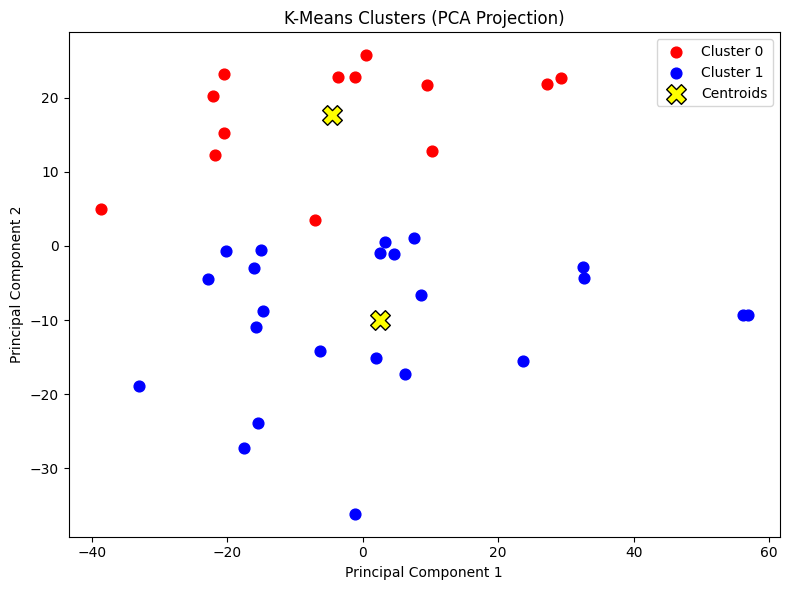

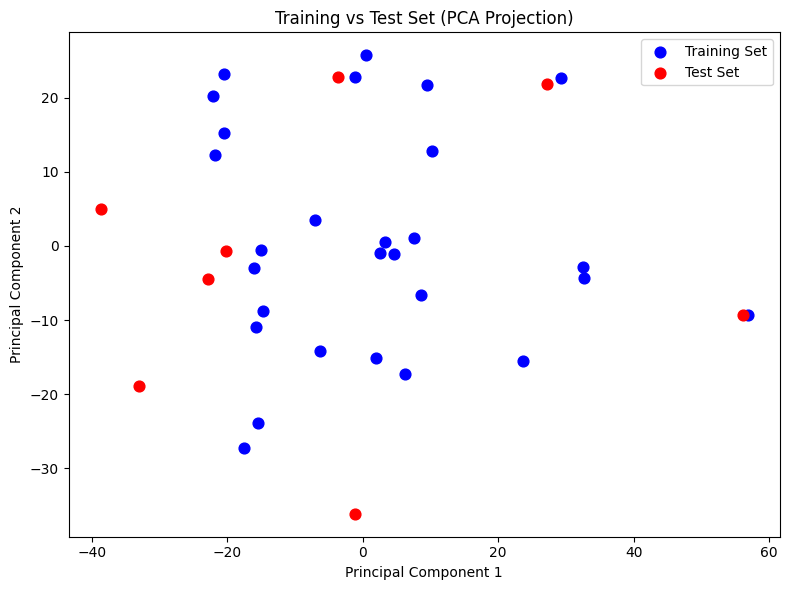

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

# ==============================
# Step 0: File paths
# ==============================
input_csv = "File path for low variance descriptors"
activity_csv = "Activity file path"
output_dir = "output file path for Data Division"
os.makedirs(output_dir, exist_ok=True)

# ==============================
# Step 1: Load cleaned descriptors and activity
# ==============================
df = pd.read_csv(input_csv)
activity_df = pd.read_csv(activity_csv)

df.columns = df.columns.str.strip()
activity_df.columns = activity_df.columns.str.strip()

if df.shape[0] == activity_df.shape[0]:
    df["Activity"] = activity_df["Activity"]
else:
    raise ValueError("Row counts do not match! Check descriptor and activity files.")

# ==============================
# Step 2: Define X and y
# ==============================
descriptor_cols = [col for col in df.columns if col not in ["Molecule", "Activity"]]
X = df[descriptor_cols]
y = df["Activity"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(df[["Molecule", "Activity"]].head())

# ==============================
# Step 3: Standardize descriptors
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# Step 4: K-Means clustering
# ==============================
kmeans = KMeans(n_clusters=2, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(df["Cluster"].value_counts())

print("\nActivity stats per cluster:")
print(df.groupby("Cluster")["Activity"].describe())

# ==============================
# Step 5: PCA projection (2D for visualization)
# ==============================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

centroids_pca = pca.transform(kmeans.cluster_centers_)

# ==============================
# Step 6: Split into training and test sets (WITH activity alignment)
# ==============================

# First, split and KEEP indices YOU CAN CHANGE TRAIN AND TEST SET PERCENTAGE
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Cluster"]
)

# Extract corresponding activity splits
activity_train = train_df[["Molecule", "Activity"]].copy()
activity_test = test_df[["Molecule", "Activity"]].copy()

# Save descriptor + activity combined (as before)
train_csv = os.path.join(output_dir, "Data_train.csv")
test_csv = os.path.join(output_dir, "Data_test.csv")

train_df.to_csv(train_csv, index=False)
test_df.to_csv(test_csv, index=False)

# Save activity separately (NEW)
activity_train_csv = os.path.join(output_dir, "Activity_train.csv")
activity_test_csv = os.path.join(output_dir, "Activity_test.csv")

activity_train.to_csv(activity_train_csv, index=False)
activity_test.to_csv(activity_test_csv, index=False)

print("\nTraining and test sets saved (including activity splits).")

# Step 7: Plot 1 - KMeans Cluster Scatter
# ==============================
plt.figure(figsize=(8,6))

colors = ["red", "blue", "green", "purple", "orange"]

for cluster_id in sorted(df["Cluster"].unique()):
    cluster_data = df[df["Cluster"] == cluster_id]
    plt.scatter(cluster_data["PC1"],
                cluster_data["PC2"],
                s=60,
                color=colors[cluster_id],
                label=f"Cluster {cluster_id}")

plt.scatter(centroids_pca[:, 0],
            centroids_pca[:, 1],
            s=200,
            c="yellow",
            marker="X",
            edgecolor="black",
            label="Centroids")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters (PCA Projection)")
plt.legend()
plt.tight_layout()

cluster_plot_path = os.path.join(output_dir, "kmeans_cluster_scatter.png")
plt.savefig(cluster_plot_path)
plt.show()

# ==============================
# Step 8: Plot 2 - Training vs Test Scatter
# ==============================
plt.figure(figsize=(8,6))

plt.scatter(train_df["PC1"],
            train_df["PC2"],
            color="blue",
            s=60,
            label="Training Set")

plt.scatter(test_df["PC1"],
            test_df["PC2"],
            color="red",
            s=60,
            label="Test Set")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Training vs Test Set (PCA Projection)")
plt.legend()
plt.tight_layout()

split_plot_path = os.path.join(output_dir, "train_test_scatter.png")
plt.savefig(split_plot_path)
plt.show()

# **Pearson Correlation Analysis for Descriptor Relevance**

# Measures relationship between descriptors and activity
# Outputs:

# correlation coefficient (r)
# p-value (significance)

In [ ]:
import pandas as pd
import numpy as np
import os
from scipy.stats import pearsonr

# ==============================
# Paths
# ==============================
input_csv = "Use your train set file path"
activity_csv = "Use the activity train set file path"
output_dir = "Output file path for the Analysis"
os.makedirs(output_dir, exist_ok=True)

# ==============================
# Load data
# ==============================
df = pd.read_csv(input_csv)
activity_df = pd.read_csv(activity_csv)

df.columns = df.columns.str.strip()
activity_df.columns = activity_df.columns.str.strip()

if df.shape[0] == activity_df.shape[0]:
    df["Activity"] = activity_df["Activity"]
else:
    raise ValueError("Row counts do not match!")

# Ensure numeric
y = pd.to_numeric(df["Activity"], errors="coerce")

# ==============================
# Define X
# ==============================
descriptor_cols = [c for c in df.columns if c not in ["Molecule", "Activity"]]
X = df[descriptor_cols]

# ==============================
# Pearson calculation (robust)
# ==============================
results = []

for col in descriptor_cols:
    try:
        valid = X[col].notna() & y.notna()

        if valid.sum() > 2 and X[col][valid].std() > 1e-6:
            r, p = pearsonr(X[col][valid], y[valid])
        else:
            r, p = np.nan, np.nan
    except:
        r, p = np.nan, np.nan

    results.append([col, r, p])

corr_df = pd.DataFrame(results, columns=["Descriptor", "Pearson_r", "p_value"])

# Clean results
corr_df = corr_df.dropna(subset=["Pearson_r", "p_value"])

# Ranking
corr_df["abs_r"] = corr_df["Pearson_r"].abs()
corr_df = corr_df.sort_values(by="abs_r", ascending=False)

# Save
corr_df.to_csv(os.path.join(output_dir, "pearson_results.csv"), index=False)

print("\nTop descriptors:")
print(corr_df.head(10))


Top descriptors:
       Descriptor  Pearson_r   p_value     abs_r
1019      Mor23se   0.647114  0.000198  0.647114
1283   PEOE_VSA10  -0.640766  0.000239  0.640766
194         DPSA3  -0.636921  0.000268  0.636921
1313  EState_VSA7   0.631384  0.000315  0.631384
727        Mor23v   0.626767  0.000359  0.626767
421        ATS3dv  -0.623125  0.000397  0.623125
395        AATS7i  -0.618230  0.000455  0.618230
726        Mor23p   0.618185  0.000455  0.618185
254         Mor23   0.615370  0.000492  0.615370
397        AATS7p   0.613991  0.000510  0.613991


# **Initial Multicollinearity Assessment (VIF and Correlation Matrix)**

# **Detects redundancy among descriptors**

Descriptor matrix shape: (28, 1380)


/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)



Top 15 descriptors with highest VIF:
                         Descriptor  VIF
1379                            PC2  inf
0                            energy  inf
1                                MW  inf
2                                MZ  inf
1363                        MDEC-12  inf
1362                        MAXsCH3  inf
1361                         MINssO  inf
1360                         MAXssO  inf
1359  global_electrophilicity_index  inf
1358             GeomPetitjeanIndex  inf
1357                 TopoShapeIndex  inf
1356                 PetitjeanIndex  inf
1355                 GeomShapeIndex  inf
1354                 ETA_dEpsilon_D  inf
1353                 ETA_dEpsilon_C  inf


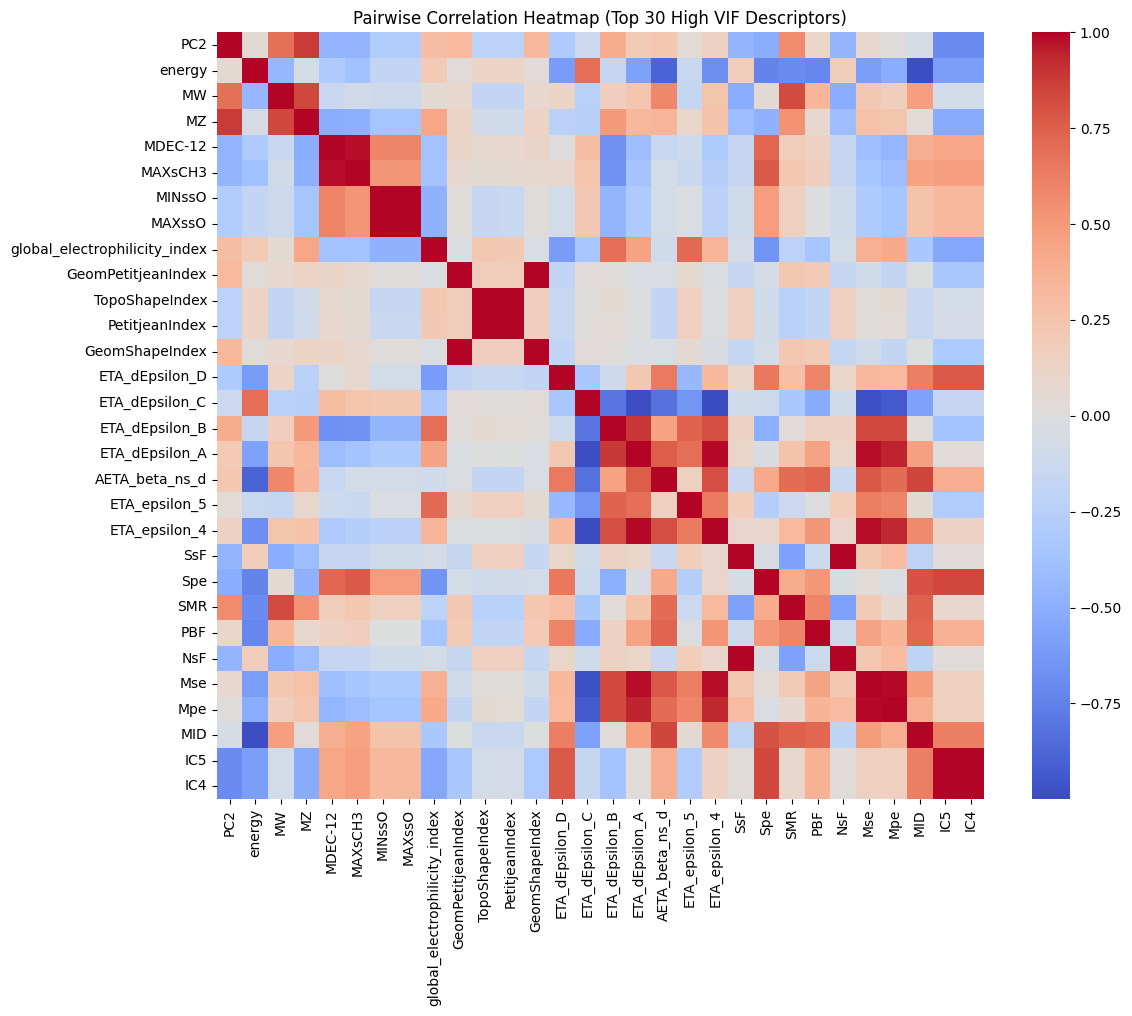


All results saved in: /content/drive/MyDrive/Webinar/rowan/Multicollinearity_Results/


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# ==============================
# Step 0: File paths
# ==============================
input_csv = "Use th same file path you used for the pearson analysis"
output_dir = "ouput file path for your firt multicollinearity assesment "
os.makedirs(output_dir, exist_ok=True)

# ==============================
# Step 1: Load dataset
# ==============================
df = pd.read_csv(input_csv)
df.columns = df.columns.str.strip()

# Remove non-numeric columns
if "Molecule" in df.columns:
    df = df.drop(columns=["Molecule"])

# Keep only numeric columns
df = df.select_dtypes(include=[np.number])

print("Descriptor matrix shape:", df.shape)

# ==============================
# Step 2: Standardize descriptors (important for VIF stability)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

# ==============================
# Step 3: Calculate VIF
# ==============================
vif_data = pd.DataFrame()
vif_data["Descriptor"] = X_scaled_df.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled_df.values, i)
    for i in range(X_scaled_df.shape[1])
]

# Sort by highest VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_path = os.path.join(output_dir, "VIF_results.csv")
vif_data.to_csv(vif_path, index=False)

print("\nTop 15 descriptors with highest VIF:")
print(vif_data.head(15))

# ==============================
# Step 4: Pairwise Correlation Matrix
# ==============================
corr_matrix = df.corr(method="pearson")

corr_path = os.path.join(output_dir, "pairwise_correlation_matrix.csv")
corr_matrix.to_csv(corr_path)

# ==============================
# Step 5: Heatmap (Top 30 most correlated descriptors by VIF)
# ==============================
top_features = vif_data["Descriptor"].head(30)
corr_subset = corr_matrix.loc[top_features, top_features]

plt.figure(figsize=(12,10))
sns.heatmap(
    corr_subset,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Pairwise Correlation Heatmap (Top 30 High VIF Descriptors)")
plt.tight_layout()

heatmap_path = os.path.join(output_dir, "pairwise_correlation_heatmap.png")
plt.savefig(heatmap_path)
plt.show()

print("\nAll results saved in:", output_dir)

# **Feature Selection Based on Pearson Correlation**

In [ ]:
import pandas as pd
import os

# ==============================
# Paths (consistent with your workflow)
# ==============================
descriptor_file = "Use your training set  file path"
activity_file = "Activity_train.csv file path"
pearson_results = "Use the pearson correlation analysis results file path"

output_path = "file path for your first feature selection"
os.makedirs(output_path, exist_ok=True)

# ==============================
# Load data
# ==============================
df = pd.read_csv(descriptor_file)
activity_df = pd.read_csv(activity_file)
pearson_df = pd.read_csv(pearson_results)

# Clean columns
df.columns = df.columns.str.strip()
pearson_df.columns = pearson_df.columns.str.strip()

# Add activity
df["Activity"] = activity_df["Activity"]

# ==============================
# Apply filtering (correct thresholds) HERE IS WHERE YOU CAN SET YOUR THRESHOLD
# ==============================
filtered = pearson_df[
    (pearson_df["abs_r"] >= 0.5) &
    (pearson_df["p_value"] <= 0.01)
]

# Sort for clarity
filtered = filtered.sort_values(by="abs_r", ascending=False)

# ==============================
# Match descriptors with dataset
# ==============================
selected_descriptors = [
    col for col in filtered["Descriptor"]
    if col in df.columns
]

# ==============================
# Create filtered dataset
# ==============================
df_step1 = df[selected_descriptors + ["Activity"]]

# ==============================
# Save outputs
# ==============================
df_step1.to_csv(os.path.join(output_path, "dataset_after_step1.csv"), index=False)
filtered.to_csv(os.path.join(output_path, "filtered_descriptors_step1.csv"), index=False)

# ==============================
# Diagnostics
# ==============================
print("Descriptors kept after Step 1:", len(selected_descriptors))
print("\nTop descriptors:")
print(filtered.head(10))

Descriptors kept after Step 1: 121

Top descriptors:
    Descriptor  Pearson_r   p_value     abs_r
0      Mor23se   0.647114  0.000198  0.647114
1   PEOE_VSA10  -0.640766  0.000239  0.640766
2        DPSA3  -0.636921  0.000268  0.636921
3  EState_VSA7   0.631384  0.000315  0.631384
4       Mor23v   0.626767  0.000359  0.626767
5       ATS3dv  -0.623125  0.000397  0.623125
6       AATS7i  -0.618230  0.000455  0.618230
7       Mor23p   0.618185  0.000455  0.618185
8        Mor23   0.615370  0.000492  0.615370
9       AATS7p   0.613991  0.000510  0.613991


# **Detailed Multicollinearity Inspection**

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


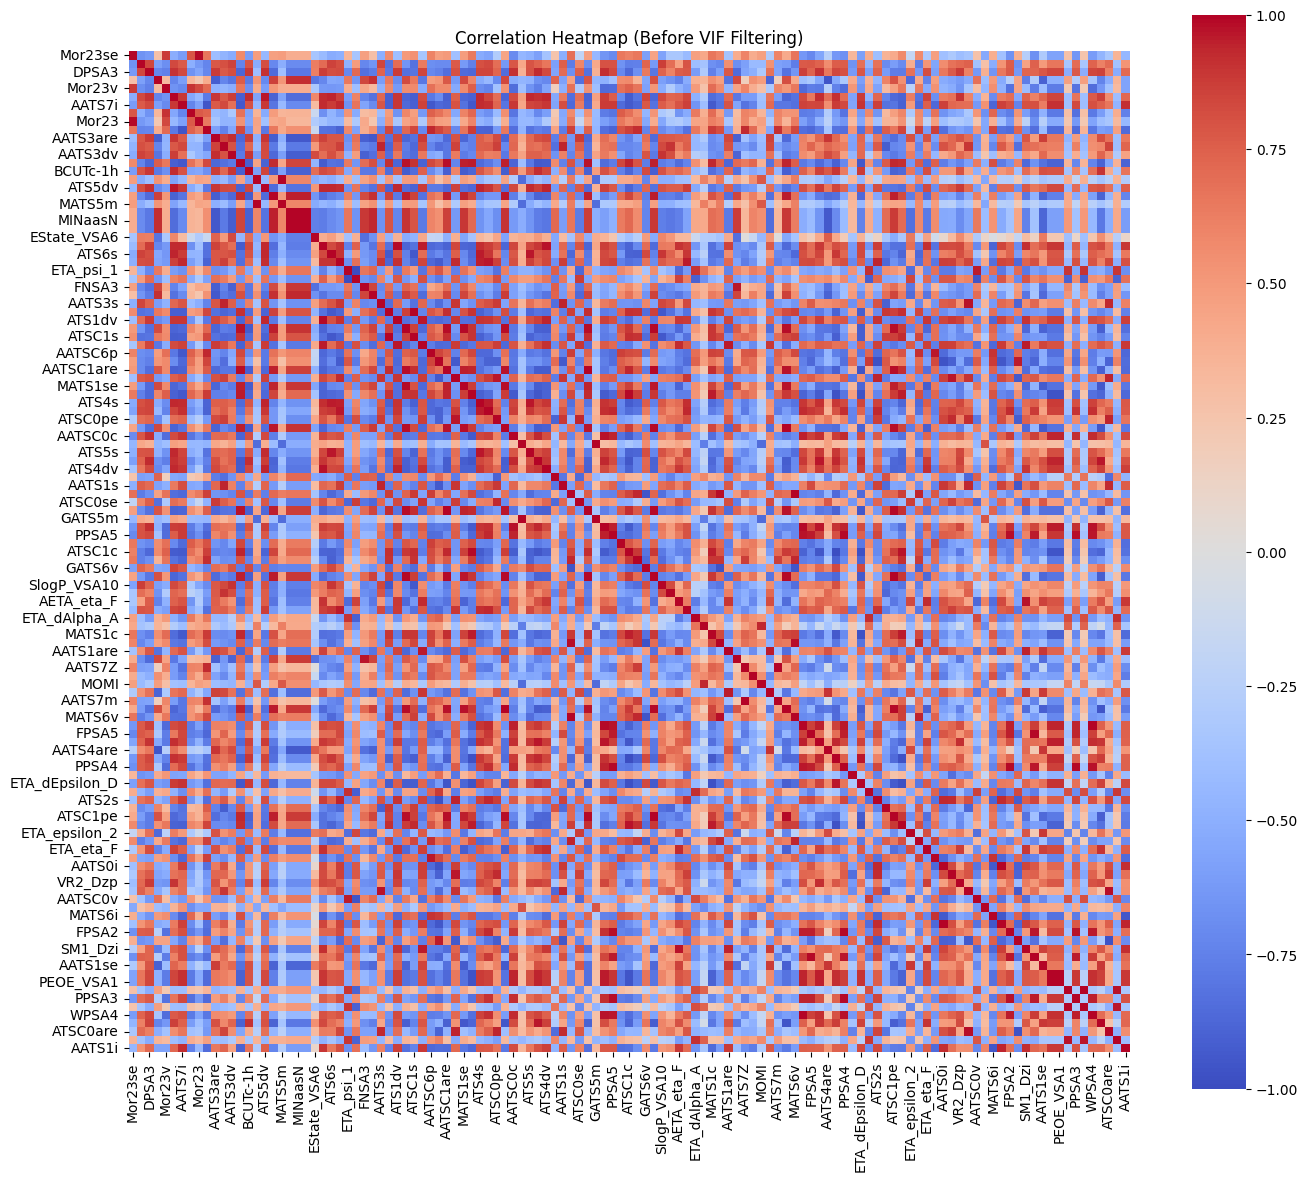


Top 20 VIF values:
 Descriptor  VIF
    Mor23se  inf
 PEOE_VSA10  inf
      DPSA3  inf
EState_VSA7  inf
     Mor23v  inf
     ATS3dv  inf
     AATS7i  inf
     Mor23p  inf
      Mor23  inf
     AATS7p  inf
   AATS3are  inf
     AATS4s  inf
    AATS3dv  inf
   MATS1are  inf
   BCUTc-1h  inf
     MATS5Z  inf
     ATS5dv  inf
    MAXaasC  inf
     MATS5m  inf
    MAXaasN  inf

Total number of descriptors: 121
Highly correlated pairs (|r| > 0.8): 1563

Top correlated pairs:
Descriptor_1 Descriptor_2  Correlation
   ETA_psi_1   ETA_dPsi_A    -1.000000
     MAXaasN        SaasN     1.000000
     MAXaasN      MINaasN     1.000000
     MINaasN        SaasN     1.000000
  SlogP_VSA1    PEOE_VSA1     1.000000
      MATS5Z       MATS5m     0.999576
      GATS5Z       GATS5m     0.998993
    BCUTm-1h     BCUTZ-1h     0.998779
      AATS7Z       AATS7m     0.998656
     AATSC1s       ATSC1s     0.998294


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# ==============================
# Paths
# ==============================
input_file = "Use the file path for the first feature reduction Based on correlation with Activity filtering"
output_path = "set the output file path for your second multicollinearity check"
os.makedirs(output_path, exist_ok=True)

# ==============================
# Load dataset
# ==============================
df = pd.read_csv(input_file)

# Separate descriptors and target
X = df.drop(columns=["Activity"])
y = df["Activity"]

# ==============================
# Standardize descriptors
# ==============================
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# ==============================
# VIF Calculation (NO filtering)
# ==============================
vif_data = pd.DataFrame()
vif_data["Descriptor"] = X_scaled.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled.values, i)
    for i in range(X_scaled.shape[1])
]

# Sort by highest VIF
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# ==============================
# Save VIF results
# ==============================
vif_data.to_csv(os.path.join(output_path, "vif_full.csv"), index=False)

# Save top 20 separately
top20_vif = vif_data.head(20)
top20_vif.to_csv(os.path.join(output_path, "top20_vif.csv"), index=False)

# ==============================
# Correlation matrix
# ==============================
corr_matrix = X.corr()
corr_matrix.to_csv(os.path.join(output_path, "correlation_matrix.csv"))

# ==============================
# Heatmap
# ==============================
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    square=True
)

plt.title("Correlation Heatmap (Before VIF Filtering)")
plt.tight_layout()
plt.savefig(os.path.join(output_path, "heatmap_before_vif.png"), dpi=300)
plt.show()

# ==============================
# Find highly correlated pairs YOU CAN SET YOUR THRESHOLD VALUE
# ==============================
threshold = 0.8

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_value
            ))

high_corr_df = pd.DataFrame(
    high_corr_pairs,
    columns=["Descriptor_1", "Descriptor_2", "Correlation"]
).sort_values(by="Correlation", key=abs, ascending=False)

# Save correlated pairs
high_corr_df.to_csv(os.path.join(output_path, "high_correlation_pairs.csv"), index=False)

# ==============================
# Diagnostics (PRINT TOP 20)
# ==============================
print("\nTop 20 VIF values:")
print(top20_vif.to_string(index=False))

print("\nTotal number of descriptors:", X.shape[1])
print("Highly correlated pairs (|r| > 0.8):", len(high_corr_df))

print("\nTop correlated pairs:")
print(high_corr_df.head(10).to_string(index=False))

# **Data Preprocessing and Multicollinearity Removal.**

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ==============================
# 1. FILE PATHS (EDIT)
# ==============================
input_file = "Use the file path for the first feature reduction Based on correlation with Activity filtering"
output_file = "output file path for your second feature selection results"

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv(input_file)

# ==============================
# 3. DEFINE TARGET COLUMN
# ==============================
target_column = "Activity"  # <-- IMPORTANT (set correctly)

# Separate X and y
if target_column in df.columns:
    y = df[target_column]
    X = df.drop(columns=[target_column])
else:
    raise ValueError(f"Target column '{target_column}' not found in dataset.")

print(f"Initial shape (X only): {X.shape}")

# ==============================
# 4. REMOVE CONSTANT FEATURES
# ==============================
constant_cols = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=constant_cols)

print(f"Removed constant features: {len(constant_cols)}")
print(f"Shape after constant removal: {X.shape}")

# ==============================
# 5. REMOVE PERFECT CORRELATIONS
# ==============================
corr_matrix = X.corr()

to_drop_perfect = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) == 1:
            colname = corr_matrix.columns[i]
            to_drop_perfect.add(colname)

X = X.drop(columns=list(to_drop_perfect))

print(f"Removed perfectly correlated features: {len(to_drop_perfect)}")
print(f"Shape after perfect correlation removal: {X.shape}")

# ==============================
# 6. CORRELATION FILTERING  SET THE THRESHOLD
# ==============================
threshold = 0.90  # adjust if needed

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [col for col in upper.columns if any(upper[col] > threshold)]
X = X.drop(columns=to_drop_corr)

print(f"Removed high correlation features (> {threshold}): {len(to_drop_corr)}")
print(f"Shape after correlation filtering: {X.shape}")

# ==============================
# 7. VIF FUNCTION
# ==============================
def calculate_vif(data):
    vif_data = pd.DataFrame()
    vif_data["feature"] = data.columns
    vif_data["VIF"] = [
        variance_inflation_factor(data.values, i)
        for i in range(data.shape[1])
    ]
    return vif_data

# ==============================
# 8. ITERATIVE VIF REMOVAL
# ==============================
vif_threshold = 10

while True:
    vif_df = calculate_vif(X)
    max_vif = vif_df["VIF"].max()

    if max_vif < vif_threshold:
        break

    drop_feature = vif_df.sort_values("VIF", ascending=False)["feature"].iloc[0]
    print(f"Dropping {drop_feature} with VIF = {max_vif:.2f}")
    X = X.drop(columns=[drop_feature])

print("Final VIF filtering complete")
print(f"Final shape (X only): {X.shape}")

# ==============================
# 9. FINAL VIF REPORT
# ==============================
final_vif = calculate_vif(X).sort_values(by="VIF", ascending=False)

print("\nFinal VIF values:")
print(final_vif)

# ==============================
# 10. ADD TARGET BACK
# ==============================
final_df = pd.concat([X, y], axis=1)

# ==============================
# 11. SAVE DATASET
# ==============================
final_df.to_csv(output_file, index=False)

print(f"\nFiltered dataset saved to: {output_file}")

Initial shape (X only): (28, 121)
Removed constant features: 0
Shape after constant removal: (28, 121)
Removed perfectly correlated features: 3
Shape after perfect correlation removal: (28, 118)
Removed high correlation features (> 0.9): 96
Shape after correlation filtering: (28, 22)
Dropping EState_VSA7 with VIF = 1442.77
Dropping ETA_psi_1 with VIF = 651.35
Dropping Mor23p with VIF = 232.43
Dropping AATS7i with VIF = 93.75
Dropping DPSA3 with VIF = 86.20
Dropping GATS5Z with VIF = 29.43
Dropping ETA_dAlpha_A with VIF = 22.98
Dropping AATS4s with VIF = 18.85
Dropping Mor23v with VIF = 12.35
Dropping ETA_epsilon_2 with VIF = 11.49
Dropping PEOE_VSA10 with VIF = 10.64
Final VIF filtering complete
Final shape (X only): (28, 11)

Final VIF values:
        feature       VIF
6        MOMI-Y  4.934192
5     PEOE_VSA8  4.873436
4       AATSC6v  4.781498
1        MATS5Z  4.630890
9        GATS5p  4.197094
3       MINaasC  4.123469
2   EState_VSA6  3.361670
10     BCUTm-1h  3.111677
0       Mor

# **Principal Component Analysis (PCA)**

Number of descriptors after Step 2: 11
Number of molecules: 28


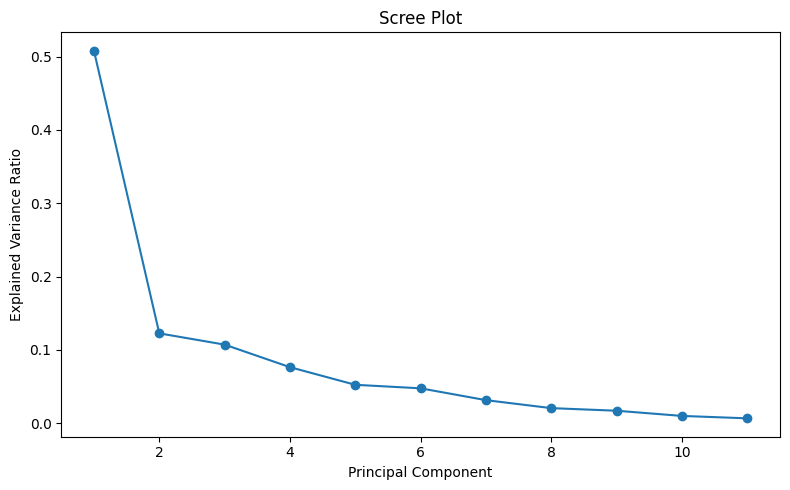

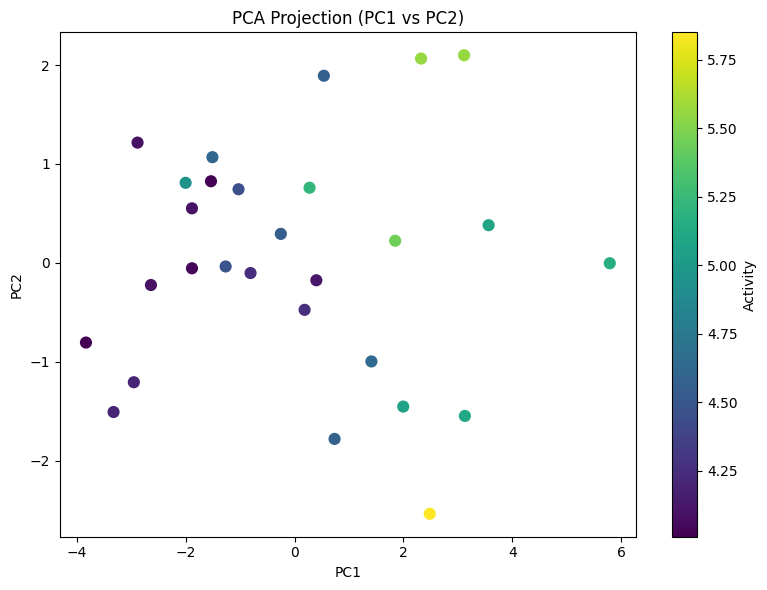


PCA results saved in: /content/drive/MyDrive/Webinar/rowan/PCA_Results/


In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ==============================
# File paths
# ==============================
input_csv = " the file path for your second feature selection"
output_dir = "output file path for PCA results"
os.makedirs(output_dir, exist_ok=True)

# ==============================
# Load dataset
# ==============================
df = pd.read_csv(input_csv)

descriptor_cols = [col for col in df.columns if col != "Activity"]

X = df[descriptor_cols]
y = df["Activity"]

print("Number of descriptors after Step 2:", X.shape[1])
print("Number of molecules:", X.shape[0])

# ==============================
# Standardize features
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# Perform PCA
# ==============================
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_

# Save explained variance
variance_df = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained_variance))],
    "Explained_Variance_Ratio": explained_variance
})

variance_df.to_csv(os.path.join(output_dir, "pca_explained_variance.csv"), index=False)

# ==============================
# Plot 1: Scree Plot
# ==============================
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "scree_plot.png"))
plt.show()

# ==============================
# Plot 2: PC1 vs PC2
# ==============================
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="viridis", s=60)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (PC1 vs PC2)")
plt.colorbar(scatter, label="Activity")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "pca_scatter_PC1_PC2.png"))
plt.show()

print("\nPCA results saved in:", output_dir)

# **Automated Feature Selection Using LASSO Regression**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

# ==============================
# 1. FILE PATH
# ==============================
input_file = "use last feature selection file path"

# ==============================
# 2. LOAD DATA
# ==============================
df = pd.read_csv(input_file)

target_column = "Activity"

X = df.drop(columns=[target_column])
y = df[target_column]

print(f"Input shape: {X.shape}")

# ==============================
# 3. SCALE FEATURES (IMPORTANT)
# ==============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==============================
# 4. LASSO WITH CROSS-VALIDATION
# ==============================
lasso = LassoCV(
    cv=5,              # cross-validation
    random_state=42,
    max_iter=10000
)

lasso.fit(X_scaled, y)

print(f"Best alpha (lambda): {lasso.alpha_}")

# ==============================
# 5. EXTRACT SELECTED FEATURES
# ==============================
coef = pd.Series(lasso.coef_, index=X.columns)

selected_features = coef[coef != 0].index.tolist()
removed_features = coef[coef == 0].index.tolist()

print(f"\nSelected features ({len(selected_features)}):")
print(selected_features)

print(f"\nRemoved features ({len(removed_features)}):")
print(removed_features)

# ==============================
# 6. CREATE FINAL DATASET
# ==============================
X_selected = X[selected_features]
final_df = pd.concat([X_selected, y], axis=1)

# ==============================
# 7. SAVE OUTPUT
# ==============================
output_file = "output file path for Final_Selection"
final_df.to_csv(output_file, index=False)

print(f"\nSaved LASSO-selected dataset to: {output_file}")

# ==============================
# 8. COEFFICIENT IMPORTANCE
# ==============================
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nFeature importance (LASSO coefficients):")
print(coef_df)

Input shape: (28, 11)
Best alpha (lambda): 0.030504409009304612

Selected features (8):
['Mor23se', 'MATS5Z', 'EState_VSA6', 'MOMI-Y', 'Mor04p', 'GATS6dv', 'GATS5p', 'BCUTm-1h']

Removed features (3):
['MINaasC', 'AATSC6v', 'PEOE_VSA8']

Saved LASSO-selected dataset to: /content/drive/MyDrive/Webinar/rowan/Step1_Pearson_Filter/Final_Selection.csv

Feature importance (LASSO coefficients):
        Feature  Coefficient
2   EState_VSA6    -0.171981
0       Mor23se     0.151646
8       GATS6dv     0.088010
7        Mor04p     0.081209
9        GATS5p    -0.047408
6        MOMI-Y     0.035101
10     BCUTm-1h     0.018430
1        MATS5Z     0.001928
5     PEOE_VSA8     0.000000
3       MINaasC     0.000000
4       AATSC6v     0.000000


# **Combinatorial Search for Optimal MLR Models**

In [ ]:
import pandas as pd
import numpy as np
import itertools

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

# ==============================
# Load TRAIN data
# ==============================
train_path = "Final_Selection file path"
df_train = pd.read_csv(train_path)

# ==============================
# Load EXTERNAL TEST data
# ==============================
test_path = "test set file path"
df_test = pd.read_csv(test_path)

####### use the final descriptors you got
features = ['Mor23se', 'MATS5Z', 'EState_VSA6', 'MOMI-Y',
            'Mor04p', 'GATS6dv', 'GATS5p', 'BCUTm-1h']

target = "Activity"

X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]
y_test = df_test[target]

# ==============================
# Combinatorial search
# ==============================
results = []
### you can change the range
for k in range(2, 6):
    for combo in itertools.combinations(features, k):

        combo = list(combo)

        model = LinearRegression()
        model.fit(X_train[combo], y_train)

        # Predictions
        y_tr_pred = model.predict(X_train[combo])
        y_te_pred = model.predict(X_test[combo])

        # Metrics
        train_r2 = r2_score(y_train, y_tr_pred)
        test_r2 = r2_score(y_test, y_te_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_te_pred))

        # Q² (CV on training)
        cv_scores = cross_val_score(model, X_train[combo], y_train, cv=5, scoring='r2')
        q2 = np.mean(cv_scores)

        results.append({
            "n_features": k,
            "features": combo,
            "train_r2": train_r2,
            "test_r2_external": test_r2,
            "q2": q2,
            "test_rmse_external": test_rmse
        })

results_df = pd.DataFrame(results)

# Sort properly
results_df = results_df.sort_values(
    by=["test_r2_external", "q2"],
    ascending=False
)

print(results_df.head(10))

     n_features                                      features  train_r2  \
166           5   [Mor23se, MATS5Z, MOMI-Y, Mor04p, BCUTm-1h]  0.608663   
201           5    [MATS5Z, MOMI-Y, Mor04p, GATS5p, BCUTm-1h]  0.484802   
173           5  [Mor23se, MATS5Z, GATS6dv, GATS5p, BCUTm-1h]  0.632613   
97            4          [Mor23se, MATS5Z, GATS6dv, BCUTm-1h]  0.631634   
171           5  [Mor23se, MATS5Z, Mor04p, GATS6dv, BCUTm-1h]  0.637802   
170           5    [Mor23se, MATS5Z, Mor04p, GATS6dv, GATS5p]  0.611789   
93            4            [Mor23se, MATS5Z, Mor04p, GATS6dv]  0.609028   
96            4            [Mor23se, MATS5Z, GATS6dv, GATS5p]  0.605115   
168           5  [Mor23se, MATS5Z, MOMI-Y, GATS6dv, BCUTm-1h]  0.631774   
31            3                    [Mor23se, MATS5Z, GATS6dv]  0.596000   

     test_r2_external        q2  test_rmse_external  
166          0.842227  0.058231            0.179128  
201          0.841577 -0.238527            0.179497  
173         

# **Y-Randomization Test for Model Robustness (MLR)**

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

n_iter = 100  # number of randomizations you can change the number of randomization

 ### Change the features suit your best model features
features = ['Mor23se', 'MATS5Z', 'GATS6dv', 'BCUTm-1h']

X_tr = df_train[features]
y_tr = df_train['Activity']

X_te = df_test[features]
y_te = df_test['Activity']

original_model = LinearRegression()
original_model.fit(X_tr, y_tr)

y_pred_test = original_model.predict(X_te)
original_r2 = r2_score(y_te, y_pred_test)

random_r2_scores = []

for i in range(n_iter):
    y_random = np.random.permutation(y_tr)

    model = LinearRegression()
    model.fit(X_tr, y_random)

    y_rand_pred = model.predict(X_te)
    r2_rand = r2_score(y_te, y_rand_pred)

    random_r2_scores.append(r2_rand)

print("Original Test R²:", round(original_r2, 4))
print("Mean Random R²:", round(np.mean(random_r2_scores), 4))
print("Max Random R²:", round(np.max(random_r2_scores), 4))

Original Test R²: 0.8043
Mean Random R²: -0.317
Max Random R²: 0.3597


# **Applicability Domain Analysis (Williams Plot - MLR)**

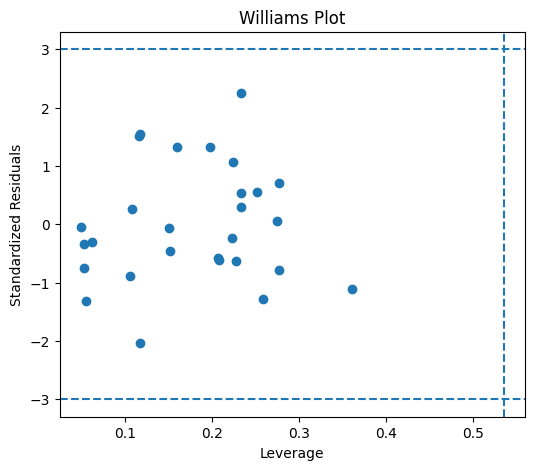

Leverage threshold: 0.5357


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = X_tr.values
y = y_tr.values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

# Residuals
residuals = y - y_pred
std_residuals = residuals / np.std(residuals)

# Hat matrix (leverage)
X_with_const = np.column_stack((np.ones(X.shape[0]), X))
H = X_with_const @ np.linalg.inv(X_with_const.T @ X_with_const) @ X_with_const.T
leverage = np.diag(H)

# Thresholds
n = X.shape[0]
p = X.shape[1]

leverage_threshold = 3 * (p + 1) / n

# Plot
plt.figure(figsize=(6,5))
plt.scatter(leverage, std_residuals)

plt.axhline(y=3, linestyle='--')
plt.axhline(y=-3, linestyle='--')
plt.axvline(x=leverage_threshold, linestyle='--')

plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("Williams Plot")

plt.show()

print("Leverage threshold:", round(leverage_threshold, 4))

# **Final VIF Analysis of Selected Descriptors**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df_train[features]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data.sort_values(by="VIF", ascending=False))

    Feature       VIF
1    MATS5Z  1.468261
0   Mor23se  1.362728
3  BCUTm-1h  1.290321
2   GATS6dv  1.280413


In [ ]:
#### change the features to suit your best model
features = ['Mor23se', 'MATS5Z', 'GATS6dv', 'BCUTm-1h']

# **Predicted vs Observed Plot**

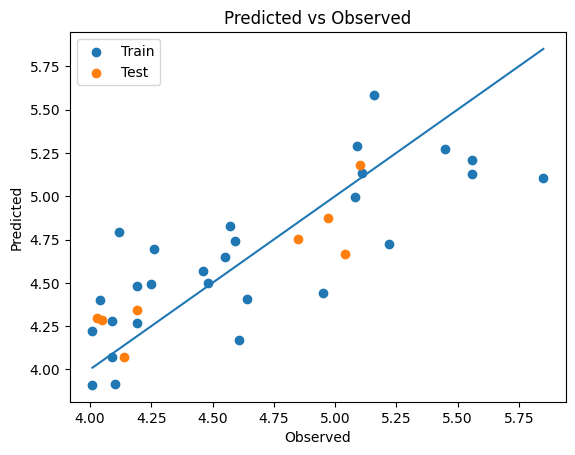

In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Train model
model = LinearRegression()
model.fit(X_train[features], y_train)

# Predictions
y_train_pred = model.predict(X_train[features])
y_test_pred = model.predict(X_test[features])

# Plot
plt.figure()
plt.scatter(y_train, y_train_pred, label="Train")
plt.scatter(y_test, y_test_pred, label="Test")

# Ideal line
min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("Predicted vs Observed")
plt.legend()

plt.show()

# **Residual Analysis for Model Diagnostics**

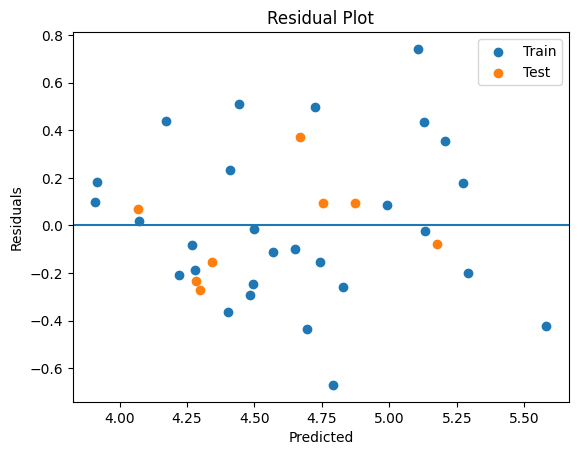

In [ ]:
# Residuals
train_residuals = y_train - y_train_pred
test_residuals = y_test - y_test_pred

plt.figure()
plt.scatter(y_train_pred, train_residuals, label="Train")
plt.scatter(y_test_pred, test_residuals, label="Test")

plt.axhline(y=0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()

plt.show()

# **Learning Curve Analysis (Model Generalization)**

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(),
    X_train[features],
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.2, 1.0, 10)
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Plot
plt.figure()
plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("R²")
plt.title("Learning Curve")
plt.legend()

plt.show()

# **Final MLR Model Summary**

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score

# ==============================
# Train model
# ==============================
model = LinearRegression()
model.fit(X_train[features], y_train)

# ==============================
# Predictions
# ==============================
y_train_pred = model.predict(X_train[features])
y_test_pred = model.predict(X_test[features])

# ==============================
# Metrics
# ==============================
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# Cross-validated Q²
cv_scores = cross_val_score(model, X_train[features], y_train, cv=5, scoring='r2')
q2 = np.mean(cv_scores)

# ==============================
# QSAR Equation
# ==============================
intercept = model.intercept_
coeffs = model.coef_

equation = f"Activity = {intercept:.4f}"

for coef, feat in zip(coeffs, features):
    sign = "+" if coef >= 0 else "-"
    equation += f" {sign} {abs(coef):.4f}*{feat}"

# ==============================
# Output
# ==============================
print("=== FINAL MLR MODEL PERFORMANCE ===")
print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")
print(f"Q² (CV)   : {q2:.4f}")

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")

print(f"Train MAE : {train_mae:.4f}")
print(f"Test MAE  : {test_mae:.4f}")

print("\n=== FINAL QSAR EQUATION ===")
print(equation)

=== FINAL MLR MODEL PERFORMANCE ===
Train R²  : 0.6316
Test R²   : 0.8043
Q² (CV)   : 0.3063
Train RMSE: 0.3289
Test RMSE : 0.1995
Train MAE : 0.2691
Test MAE  : 0.1708

=== FINAL QSAR EQUATION ===
Activity = 4.6319 + 0.2131*Mor23se + 0.1293*MATS5Z + 0.1315*GATS6dv + 0.1105*BCUTm-1h


# **Combinatorial PLS Search**

In [ ]:
import pandas as pd
import numpy as np
import itertools

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score

# ==============================
# Load datasets
# ==============================
train_path = "Final_Selection file path"
test_path  = "test set file path"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)
##### change the features to suit yours
features = ['Mor23se', 'MATS5Z', 'EState_VSA6', 'MOMI-Y',
            'Mor04p', 'GATS6dv', 'GATS5p', 'BCUTm-1h']

target = "Activity"

X_train = df_train[features]
y_train = df_train[target]

X_test = df_test[features]
y_test = df_test[target]

# ==============================
# Store results
# ==============================
results = []

# ==============================
# Combinatorial search (2–5 descriptors) you can change the range
# ==============================
for k in range(2, 6):
    for combo in itertools.combinations(features, k):

        combo = list(combo)

        # Tune number of components (important for PLS)
        for n_comp in range(1, min(len(combo), 5) + 1):

            pls = PLSRegression(n_components=n_comp)
            pls.fit(X_train[combo], y_train)

            # Predictions
            y_tr_pred = pls.predict(X_train[combo]).ravel()
            y_te_pred = pls.predict(X_test[combo]).ravel()

            # Metrics
            train_r2 = r2_score(y_train, y_tr_pred)
            test_r2  = r2_score(y_test, y_te_pred)
            test_rmse = np.sqrt(mean_squared_error(y_test, y_te_pred))

            # Q² (CV on training)
            cv_scores = cross_val_score(
                pls, X_train[combo], y_train,
                cv=5, scoring='r2'
            )
            q2 = np.mean(cv_scores)

            results.append({
                "n_features": k,
                "n_components": n_comp,
                "features": combo,
                "train_r2": train_r2,
                "test_r2_external": test_r2,
                "q2": q2,
                "test_rmse_external": test_rmse
            })

# ==============================
# Convert to DataFrame
# ==============================
results_df = pd.DataFrame(results)

# Sort by best models
results_df = results_df.sort_values(
    by=["test_r2_external", "q2"],
    ascending=False
)

print("Top 10 PLS Models:")
print(results_df.head(10))

Top 10 PLS Models:
     n_features  n_components                                      features  \
567           5             4   [Mor23se, MATS5Z, MOMI-Y, Mor04p, BCUTm-1h]   
568           5             5   [Mor23se, MATS5Z, MOMI-Y, Mor04p, BCUTm-1h]   
743           5             5    [MATS5Z, MOMI-Y, Mor04p, GATS5p, BCUTm-1h]   
742           5             4    [MATS5Z, MOMI-Y, Mor04p, GATS5p, BCUTm-1h]   
599           5             1  [Mor23se, MATS5Z, GATS6dv, GATS5p, BCUTm-1h]   
584           5             1    [Mor23se, MATS5Z, Mor04p, GATS6dv, GATS5p]   
601           5             3  [Mor23se, MATS5Z, GATS6dv, GATS5p, BCUTm-1h]   
603           5             5  [Mor23se, MATS5Z, GATS6dv, GATS5p, BCUTm-1h]   
602           5             4  [Mor23se, MATS5Z, GATS6dv, GATS5p, BCUTm-1h]   
600           5             2  [Mor23se, MATS5Z, GATS6dv, GATS5p, BCUTm-1h]   

     train_r2  test_r2_external        q2  test_rmse_external  
567  0.608654          0.842408  0.057350      

In [ ]:
features = ['Mor23se', 'MATS5Z', 'Mor04p', 'GATS6dv', 'GATS5p']
n_components = 1

# **Final PLS Model Performance**

In [ ]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score
import numpy as np

pls = PLSRegression(n_components=1)
pls.fit(X_train[features], y_train)

# Predictions
y_train_pred = pls.predict(X_train[features]).ravel()
y_test_pred  = pls.predict(X_test[features]).ravel()

# Metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse  = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae  = mean_absolute_error(y_test, y_test_pred)

# Q²
cv_scores = cross_val_score(pls, X_train[features], y_train, cv=5, scoring='r2')
q2 = np.mean(cv_scores)

print("=== PLS PERFORMANCE ===")
print(f"Train R²  : {train_r2:.4f}")
print(f"Test R²   : {test_r2:.4f}")
print(f"Q²        : {q2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE : {test_rmse:.4f}")
print(f"Train MAE : {train_mae:.4f}")
print(f"Test MAE  : {test_mae:.4f}")

=== PLS PERFORMANCE ===
Train R²  : 0.5857
Test R²   : 0.8199
Q²        : 0.3827
Train RMSE: 0.3488
Test RMSE : 0.1914
Train MAE : 0.2704
Test MAE  : 0.1611


# **Y-Randomization (PLS)**

In [ ]:
n_iter = 100
random_r2_scores = []

for i in range(n_iter):
    y_random = np.random.permutation(y_train)

    pls_rand = PLSRegression(n_components=1)
    pls_rand.fit(X_train[features], y_random)

    y_rand_pred = pls_rand.predict(X_test[features]).ravel()
    r2_rand = r2_score(y_test, y_rand_pred)

    random_r2_scores.append(r2_rand)

print("\n=== Y-RANDOMIZATION (PLS) ===")
print("Original Test R²:", round(test_r2, 4))
print("Mean Random R²:", round(np.mean(random_r2_scores), 4))
print("Max Random R²:", round(np.max(random_r2_scores), 4))


=== Y-RANDOMIZATION (PLS) ===
Original Test R²: 0.8199
Mean Random R²: -0.2811
Max Random R²: 0.7452


# **Williams Plot (PLS)**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PLSRegression was fitted with feature names
  warnings.warn(


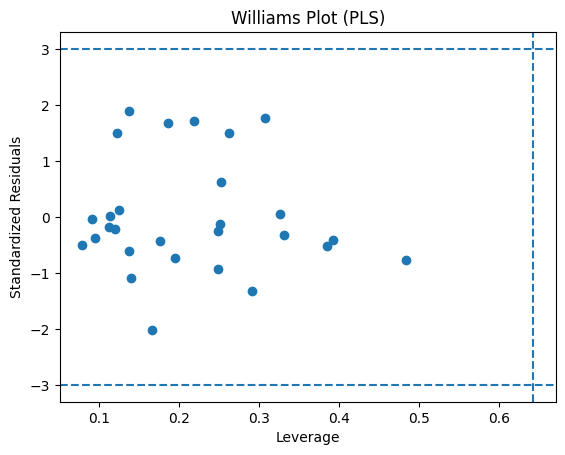

Leverage threshold: 0.6429


In [ ]:
import matplotlib.pyplot as plt

X = X_train[features].values
y = y_train.values

# Predictions
y_pred = pls.predict(X).ravel()

# Residuals
residuals = y - y_pred
std_residuals = residuals / np.std(residuals)

# Leverage
X_with_const = np.column_stack((np.ones(X.shape[0]), X))
H = X_with_const @ np.linalg.inv(X_with_const.T @ X_with_const) @ X_with_const.T
leverage = np.diag(H)

# Threshold
n = X.shape[0]
p = X.shape[1]
leverage_threshold = 3 * (p + 1) / n

# Plot
plt.figure()
plt.scatter(leverage, std_residuals)

plt.axhline(y=3, linestyle='--')
plt.axhline(y=-3, linestyle='--')
plt.axvline(x=leverage_threshold, linestyle='--')

plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("Williams Plot (PLS)")
plt.show()

print("Leverage threshold:", round(leverage_threshold, 4))

# **Multicollinearity Check for PLS**

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X_vif = X_train[features]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print("\n=== VIF (PLS descriptors) ===")
print(vif_data.sort_values(by="VIF", ascending=False))


=== VIF (PLS descriptors) ===
   Feature       VIF
4   GATS5p  2.020392
2   Mor04p  1.868040
1   MATS5Z  1.751210
0  Mor23se  1.598573
3  GATS6dv  1.305787


# **Predicted vs Observed (PLS)**

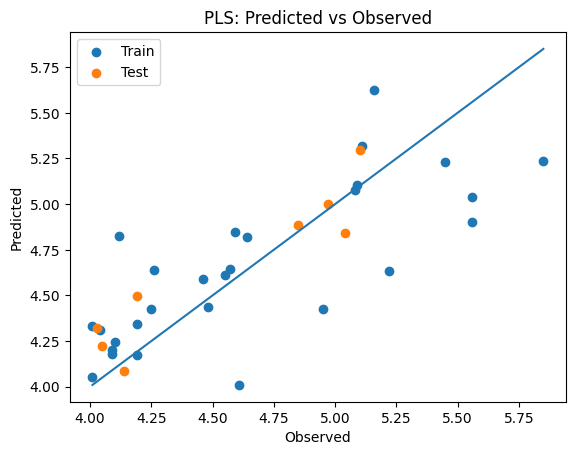

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_train, y_train_pred, label="Train")
plt.scatter(y_test, y_test_pred, label="Test")

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.title("PLS: Predicted vs Observed")
plt.legend()
plt.show()

# **Residual Plot (PLS)**

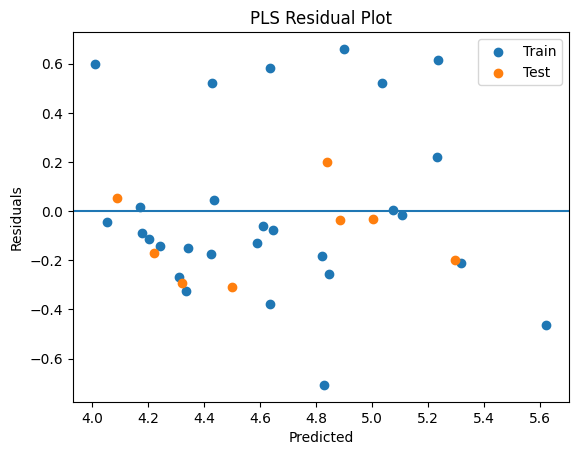

In [ ]:
train_residuals = y_train - y_train_pred
test_residuals  = y_test - y_test_pred

plt.figure()
plt.scatter(y_train_pred, train_residuals, label="Train")
plt.scatter(y_test_pred, test_residuals, label="Test")

plt.axhline(y=0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("PLS Residual Plot")
plt.legend()
plt.show()

# **PLS Learning Curve**

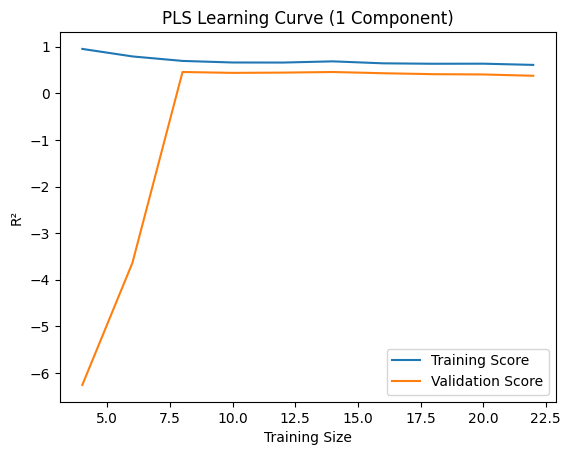

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.cross_decomposition import PLSRegression
import numpy as np
import matplotlib.pyplot as plt

pls = PLSRegression(n_components=1)

train_sizes, train_scores, val_scores = learning_curve(
    pls,
    X_train[features],
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.2, 1.0, 10)
)

# Mean scores
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

plt.figure()

plt.plot(train_sizes, train_mean, label="Training Score")
plt.plot(train_sizes, val_mean, label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("R²")
plt.title("PLS Learning Curve (1 Component)")
plt.legend()

plt.show()

# **PLS QSAR Equation**

In [ ]:
import pandas as pd
import numpy as np

pls = PLSRegression(n_components=1)
pls.fit(X_train[features], y_train)

x_mean = X_train[features].mean(axis=0)
base_pred = np.ravel(pls.predict(pd.DataFrame([x_mean], columns=features)))[0]

coeffs = []
for i in range(len(features)):
    x_plus = x_mean.copy()
    x_plus.iloc[i] += 1.0
    pred_plus = np.ravel(pls.predict(pd.DataFrame([x_plus], columns=features)))[0]
    coeffs.append(pred_plus - base_pred)

coeffs = np.array(coeffs)
intercept = base_pred - np.sum(coeffs * x_mean.values)

equation = f"Activity = {intercept:.4f}"
for coef, feat in zip(coeffs, features):
    sign = "+" if coef >= 0 else "-"
    equation += f" {sign} {abs(coef):.4f}*{feat}"

print("=== PLS QSAR EQUATION ===")
print(equation)

=== PLS QSAR EQUATION ===
Activity = 4.6510 + 0.1289*Mor23se + 0.1132*MATS5Z + 0.1075*Mor04p + 0.1118*GATS6dv - 0.1059*GATS5p


# **VIRTUAL SCREENING WITH THE MODELS**

In [ ]:
import pandas as pd

new_path = "Descriptors file path for your compounds"
df_new = pd.read_csv(new_path)

print(df_new.head())

  Name                                  UUID                item_type  \
0   24  abe1d272-6de1-452c-be89-366ec255fd07  Descriptors calculation   
1   23  ef7bd69a-a842-4241-94c2-728777d1d0a8  Descriptors calculation   
2   22  59088231-5d22-4f26-9645-e7f9686915f9  Descriptors calculation   
3   20  492dce99-2796-4c17-ad38-5f15cdb63244  Descriptors calculation   
4   21  b144b46c-6f27-4652-9eee-9dc24e31c0f4  Descriptors calculation   

      status  all_CH  all_CX  atoms  calc_engine  calc_settings  \
0  Completed     NaN     NaN    NaN          NaN            NaN   
1  Completed     NaN     NaN    NaN          NaN            NaN   
2  Completed     NaN     NaN    NaN          NaN            NaN   
3  Completed     NaN     NaN    NaN          NaN            NaN   
4  Completed     NaN     NaN    NaN          NaN            NaN   

   cofolding_model  ...  MAXsBr  MINsBr   MAXsF   MINsF  MAXsNH2  MDEN-12  \
0              NaN  ...     NaN     NaN     NaN     NaN      NaN      NaN   
1   

In [ ]:
### Define the model features
mlr_features = ['Mor23se', 'MATS5Z', 'GATS6dv', 'BCUTm-1h']

In [ ]:
### Define the model features
pls_features = ['Mor23se', 'MATS5Z', 'Mor04p', 'GATS6dv', 'GATS5p']

In [ ]:
print("Missing MLR features:", set(mlr_features) - set(df_new.columns))
print("Missing PLS features:", set(pls_features) - set(df_new.columns))

Missing MLR features: set()
Missing PLS features: set()


In [ ]:
from sklearn.linear_model import LinearRegression

# Initialize and train the MLR model
mlr_model = LinearRegression()
mlr_model.fit(X_train[mlr_features], y_train)

# MLR predictions
df_new["pIC50_MLR"] = mlr_model.predict(df_new[mlr_features])

# PLS predictions
df_new["pIC50_PLS"] = pls.predict(df_new[pls_features]).ravel()

In [ ]:
### not really needed
df_new["Difference"] = df_new["pIC50_PLS"] - df_new["pIC50_MLR"]

print(df_new[["pIC50_MLR", "pIC50_PLS", "Difference"]].head())

   pIC50_MLR  pIC50_PLS  Difference
0   8.553663   4.559582   -3.994081
1   8.139917   4.561517   -3.578400
2  13.491387   4.582227   -8.909160
3   8.169832   4.544415   -3.625417
4  13.519209   4.657158   -8.862052


Leverage threshold: 0.6429


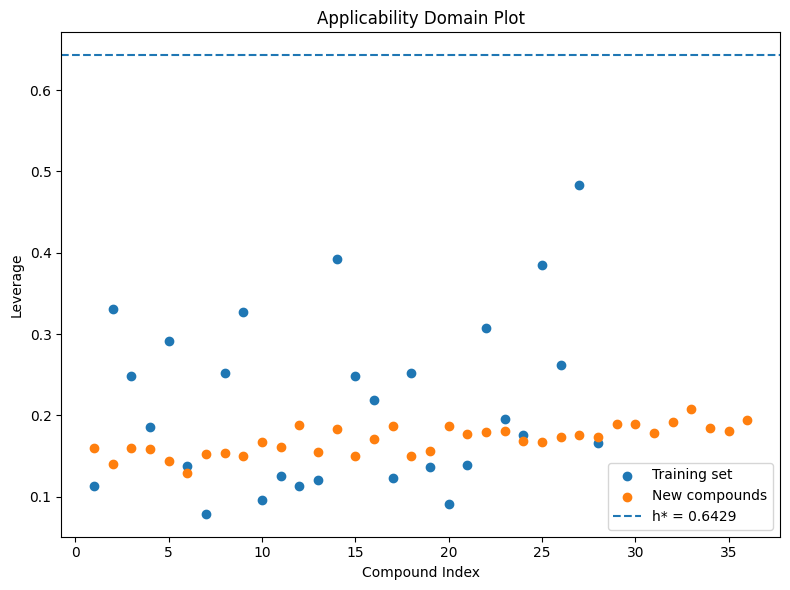

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_train_vals = X_train[pls_features].values
X_new_vals = df_new[pls_features].values

# Leverage calculation for training set
X_with_const = np.column_stack((np.ones(X_train_vals.shape[0]), X_train_vals))
H = X_with_const @ np.linalg.inv(X_with_const.T @ X_with_const) @ X_with_const.T
train_leverage = np.diag(H)

# Leverage calculation for new compounds
X_train_with_const = np.column_stack((np.ones(X_train_vals.shape[0]), X_train_vals))
X_new_with_const = np.column_stack((np.ones(X_new_vals.shape[0]), X_new_vals))
H_new = X_new_with_const @ np.linalg.inv(X_train_with_const.T @ X_train_with_const) @ X_new_with_const.T
leverage_new = np.diag(H_new)

# Threshold
n = X_train_vals.shape[0]
p = X_train_vals.shape[1]
h_star = 3 * (p + 1) / n

# Store results
df_new["Leverage"] = leverage_new
df_new["In_AD"] = df_new["Leverage"] < h_star

print("Leverage threshold:", round(h_star, 4))

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(range(1, len(train_leverage) + 1), train_leverage, label="Training set")
plt.scatter(range(1, len(leverage_new) + 1), leverage_new, label="New compounds")
plt.axhline(y=h_star, linestyle="--", label=f"h* = {h_star:.4f}")

plt.xlabel("Compound Index")
plt.ylabel("Leverage")
plt.title("Applicability Domain Plot")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
output_path = "output ile path for your prediction"
df_new.to_csv(output_path, index=False)

print("Saved predictions to:", output_path)

Saved predictions to: /content/drive/MyDrive/designed_predictions.csv


Standard deviation Check

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# File paths
pred_path = "/content/drive/MyDrive/designed_predictions.csv"
exp_path = "/content/drive/MyDrive/Webinar/Activity.csv"

# Load data
df_pred = pd.read_csv(pred_path)
df_exp = pd.read_csv(exp_path)

# Add 'Molecule' column to df_pred for merging, assuming index corresponds to mol_X
df_pred['Molecule'] = [f'mol_{i}' for i in df_pred.index]
df_exp['Molecule'] = [f'mol_{i}' for i in df_exp.index]

# Merge (change 'ID' if your key column is different)
df = pd.merge(df_pred, df_exp, on="Molecule")

# Rename experimental column if needed
df.rename(columns={"Activity": "Experimental"}, inplace=True)

print(df.head())

  Name                                  UUID                item_type  \
0   24  abe1d272-6de1-452c-be89-366ec255fd07  Descriptors calculation   
1   23  ef7bd69a-a842-4241-94c2-728777d1d0a8  Descriptors calculation   
2   22  59088231-5d22-4f26-9645-e7f9686915f9  Descriptors calculation   
3   20  492dce99-2796-4c17-ad38-5f15cdb63244  Descriptors calculation   
4   21  b144b46c-6f27-4652-9eee-9dc24e31c0f4  Descriptors calculation   

      status  all_CH  all_CX  atoms  calc_engine  calc_settings  \
0  Completed     NaN     NaN    NaN          NaN            NaN   
1  Completed     NaN     NaN    NaN          NaN            NaN   
2  Completed     NaN     NaN    NaN          NaN            NaN   
3  Completed     NaN     NaN    NaN          NaN            NaN   
4  Completed     NaN     NaN    NaN          NaN            NaN   

   cofolding_model  ...  MINsNH2  MAXssNH  MINssNH  pIC50_MLR  pIC50_PLS  \
0              NaN  ...      NaN      NaN      NaN   8.553663   4.559582   
1     

In [ ]:
# Difference = Predicted - Experimental
df["Diff_MLR"] = df["pIC50_MLR"] - df["Experimental"]
df["Diff_PLS"] = df["pIC50_PLS"] - df["Experimental"]

def summarize_errors(df, col):
    mean = df[col].mean()
    std = df[col].std()

    print(f"{col}")
    print(f"Mean Error (Bias): {mean:.4f}")
    print(f"Std Dev (Spread): {std:.4f}")
    print(f"Prediction ≈ Experimental ± {std:.4f}")
    print("-"*40)

summarize_errors(df, "Diff_MLR")
summarize_errors(df, "Diff_PLS")

Diff_MLR
Mean Error (Bias): 4.2914
Std Dev (Spread): 1.7573
Prediction ≈ Experimental ± 1.7573
----------------------------------------
Diff_PLS
Mean Error (Bias): -0.1051
Std Dev (Spread): 0.4912
Prediction ≈ Experimental ± 0.4912
----------------------------------------
